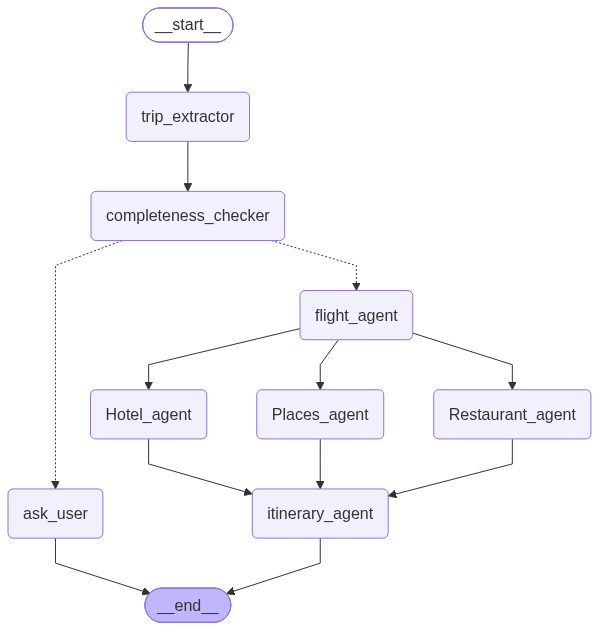

In [1]:
from langgraph.graph import StateGraph, START,END
from agents.ask_user import ask_user
from agents.completeness_checker import completeness_checker
from agents.flight_agent import flight_agent
from agents.places_agent import places_agent
from agents.hotel_agent import hotel_agent
from agents.restaurant_agent import restaurant_agent
from agents.itinerary_agent import itinerary_agent
from routers.route_trip import route_trip
from graph.state import TripState
from agents.extractor import extractor
from langgraph.checkpoint.memory import MemorySaver

builder=StateGraph(TripState)

builder.add_node("trip_extractor", extractor)
builder.add_node("ask_user", ask_user)
builder.add_node(
    "completeness_checker",
    completeness_checker
)
builder.add_node("flight_agent", flight_agent)
builder.add_node("Hotel_agent", hotel_agent)
builder.add_node("Restaurant_agent", restaurant_agent)
builder.add_node("Places_agent", places_agent)
builder.add_node("itinerary_agent", itinerary_agent)

builder.add_edge(START, "trip_extractor")
builder.add_edge("trip_extractor", "completeness_checker")
builder.add_conditional_edges(
    "completeness_checker",
    route_trip,
    {
        "flight_agent": "flight_agent",
        "ask_user": "ask_user"
    }
)
builder.add_edge("flight_agent", "Hotel_agent")
builder.add_edge("flight_agent", "Restaurant_agent")
builder.add_edge("flight_agent", "Places_agent")
builder.add_edge("Hotel_agent", "itinerary_agent")
builder.add_edge("Restaurant_agent", "itinerary_agent")
builder.add_edge("Places_agent", "itinerary_agent")

builder.add_edge("itinerary_agent", END)

checkpointer = MemorySaver()
graph = builder.compile(checkpointer=checkpointer)
graph